# 5 Families oversampling own model

In [1]:
from datetime import datetime
from __future__ import print_function, division                     # Ensures Python3 printing & division standard
import IPython.display as ipd                                       #For displaying audio in Jupyter notebooks
import json
import librosa                                                      #For audio processing                    
import matplotlib.pyplot as plt                                     #For creating plots 
import numpy as np                                                  #For numerical operations
import optuna                                                       #For hyperparameter optimization
from optuna.pruners import MedianPruner
import os                                                           #For interacting with the operating system
import pandas as pd                                                 #For data manipulation and analysis 
import random
import scipy.io.wavfile as wav
import seaborn as sns                                               #For statistical data visualization
from sklearn.metrics import roc_curve, auc, average_precision_score, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, label_binarize
import sounddevice as sd
import time
import torch
from torch import nn
import torchaudio.transforms as T
import torch.nn.functional as F                                       #For focal loss               
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from tqdm import tqdm
import urllib.request



np.random.seed(42)
random.seed(42)

In [2]:
# Set the path to data
DATA_PATH = "/Users/livajuliesmidt/Desktop/ML/AppliedML2026/FinalProject_Liva/FP_data"

dev_labels = pd.read_csv(f"{DATA_PATH}/FSD50K.ground_truth/dev.csv")
train_labels = dev_labels[dev_labels["split"] == "train"]
val_labels = dev_labels[dev_labels["split"] == "val"]
eval_labels = pd.read_csv(f"{DATA_PATH}/FSD50K.ground_truth/eval.csv")

subset_percentage = 100
print(f"Using {subset_percentage}% of the training data equaling {int(len(train_labels) * subset_percentage / 100)} samples")
train_subset = train_labels.sample(n=int(len(train_labels) * subset_percentage / 100), random_state=42)

Using 100% of the training data equaling 36796 samples


In [8]:
url = "https://raw.githubusercontent.com/audioset/ontology/master/ontology.json"
urllib.request.urlretrieve(url, "ontology.json")

with open("ontology.json") as f:
    ontology = json.load(f)

ontology_by_id = {entry["id"]: entry for entry in ontology}     # Build a lookup: mid → full entry

child_to_parent = {}                                            # Build a reverse lookup: child_mid → parent_mid
for entry in ontology:
    for child_id in entry["child_ids"]:
        child_to_parent[child_id] = entry["id"]


top_level = {                                                   # The 6 top-level family MIDs (updated to match the discovered ontology structure)
    "/m/0dgw9r": "Human sounds",
    "/m/0jbk":   "Animal",
    "/m/04rlf":  "Music",
    "/m/059j3w": "Natural sounds",
    "/t/dd00041": "Sounds of things",
    "/t/dd00098": "Source-ambiguous sounds",
}

def get_top_level_family(mid):
    current = mid
    while current not in top_level:
        parent = child_to_parent.get(current)
        if parent is None:
            return "Unknown"                                    # shouldn't happen for FSD50K classes
        current = parent
    return top_level[current]


train_subset["family"] = train_subset["mids"].apply(lambda x: get_top_level_family(x.split(",")[0]))
val_labels["family"] = val_labels["mids"].apply(lambda x: get_top_level_family(x.split(",")[0]))
eval_labels["family"] = eval_labels["mids"].apply(lambda x: get_top_level_family(x.split(",")[0]))

train_subset = train_subset[train_subset["family"] != "Source-ambiguous sounds"].reset_index(drop=True)
val_labels = val_labels[val_labels["family"] != "Source-ambiguous sounds"].reset_index(drop=True)
eval_labels = eval_labels[eval_labels["family"] != "Source-ambiguous sounds"].reset_index(drop=True)

In [4]:
#Function for extracting the spectrogram from an audio file, ensuring a fixed shape of (64, 216)
TARGET_SR = 22050                                       #Sample rate
DURATION = 5.0                                          #Seconds to keep (clip/pad to this length)
N_MELS = 64                                             #Number of mel bands to generate (bins in the spectrogram)
HOP_LENGTH = 512                                        #Number of samples between successive frames in the spectrogram
N_FRAMES = int(TARGET_SR * DURATION / HOP_LENGTH) + 1   #Number of frames in the spectrogram (~216 frames)

    
def extract_spectrogram(filepath):
    try:
        audio, sr = librosa.load(filepath, sr=TARGET_SR, duration=DURATION, mono=True)
        
        # Tile (repeat) if shorter than 5 seconds
        expected_samples = int(TARGET_SR * DURATION)
        if len(audio) < expected_samples:
            repeats = -(-expected_samples // len(audio))
            audio = np.tile(audio, repeats)[:expected_samples]
        
        mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS, hop_length=HOP_LENGTH)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = mel_db[:, :N_FRAMES]  # Trim only — padding is already handled above
        
        return mel_db  # Shape: (64, 216)
    except:
        return None
    


In [5]:
class AudioCNN_Optuna(nn.Module):
    def __init__(self, n_classes, dropout):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )
    def forward(self, x):
        return self.classifier(self.conv(x))

## Preprocessing training and validation data

In [5]:
print("Extracting 2D spectrograms from train split...")
spectrograms = []
valid_idx = []  

for i, row in tqdm(train_subset.iterrows(), total=len(train_subset)):
    filepath = f"{DATA_PATH}/FSD50K.dev_audio/{row['fname']}.wav"
    spec = extract_spectrogram(filepath)
    if spec is not None:
        spectrograms.append(spec)
        valid_idx.append(i)

X_train = np.array(spectrograms)              # (n_clips, 64, 216)
X_train = X_train[:, np.newaxis, :, :]        # (n_clips, 1, 64, 216) — channel dim for CNN
train_true = train_subset.loc[valid_idx].reset_index(drop=True) # Keep only successfully processed samples

print(f"X_train shape: {X_train.shape}")

print(f"Number of successfully processed samples: {len(train_true)}")
print(f"Number of unsuccessful samples: {len(train_subset) - len(train_true)}")

Extracting 2D spectrograms from train split...


100%|██████████| 34229/34229 [03:35<00:00, 158.67it/s]


X_train shape: (34229, 1, 64, 216)
Number of successfully processed samples: 34229
Number of unsuccessful samples: 0


In [6]:
print("Extracting 2D spectrograms from validation split...")
spectrograms = []
valid_idx = []

for i, row in tqdm(val_labels.iterrows(), total=len(val_labels)):
    filepath = f"{DATA_PATH}/FSD50K.dev_audio/{row['fname']}.wav"
    spec = extract_spectrogram(filepath)
    if spec is not None:
        spectrograms.append(spec)
        valid_idx.append(i)

X_val = np.array(spectrograms)              # (n_clips, 64, 216)
X_val = X_val[:, np.newaxis, :, :]        # (n_clips, 1, 64, 216) — channel dim for CNN
val_true = val_labels.loc[valid_idx].reset_index(drop=True) # Keep only successfully processed samples

print(f"X_val shape: {X_val.shape}")

print(f"Number of successfully processed samples: {len(val_true)}")
print(f"Number of unsuccessful samples: {len(val_labels) - len(val_true)}")


Extracting 2D spectrograms from validation split...


100%|██████████| 3719/3719 [00:27<00:00, 133.22it/s]

X_val shape: (3719, 1, 64, 216)
Number of successfully processed samples: 3719
Number of unsuccessful samples: 0


In [7]:
mean = X_train.mean()
std = X_train.std()
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std  # use train stats, not val stats!

In [8]:
le = LabelEncoder()
y_train = le.fit_transform(train_true["family"])

print(train_true["family"].value_counts())
print(f"Classes: {len(le.classes_)}, y_train shape: {y_train.shape}")

family
Sounds of things    11669
Music               11476
Human sounds         6540
Animal               2684
Natural sounds       1860
Name: count, dtype: int64
Classes: 5, y_train shape: (34229,)


In [9]:
# --- Create these ONCE, before the objective function ---
X_train_t = torch.tensor(X_train, dtype=torch.float32)                                                          #Convert training data to PyTorch tensor of type float32
y_train_t = torch.tensor(y_train, dtype=torch.long)                                                             #Convert training labels to PyTorch tensor of type long (integer class indices) 
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t  = torch.tensor(le.transform(val_true["family"]), dtype=torch.long)

n_classes = len(le.classes_)                                                                                    #Number of unique classes in the dataset
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")                                    #Use Apple Silicon GPU if available, otherwise CPU
X_val_t_device = X_val_t.to(device)

class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
sample_weights = torch.tensor([class_weights[label] for label in y_train], dtype=torch.float32)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

"""

number_of_optuna_epochs = 10       
n_trials = 30                                       

def objective(trial):
    # --- Hyperparameters to tune ---
    lr           = trial.suggest_float("lr", 1e-5, 1e-2, log=True)              #Learning rate
    dropout      = trial.suggest_float("dropout", 0.2, 0.7)                     #Dropout rate for regularization
    batch_size   = trial.suggest_categorical("batch_size", [32, 64, 128])       #Batch size for training
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)    #L2 regularization strength

    # --- Build model with tunable dropout ---
    class AudioCNN_Optuna(nn.Module):
        def __init__(self, n_classes, dropout):
            super().__init__()
            self.conv = nn.Sequential(
                nn.Conv2d(1, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),

                nn.Conv2d(32, 64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),

                nn.Conv2d(64, 128, kernel_size=3, padding=1),
                nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            )
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.LazyLinear(256),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(256, n_classes)
            )
        def forward(self, x):
            return self.classifier(self.conv(x))
    
    model = AudioCNN_Optuna(n_classes, dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)  
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=number_of_optuna_epochs, eta_min=1e-6) #eta_min is the minimum, so it does not not hit 0
    
    train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size, sampler=sampler, num_workers=0)  # no shuffle=True for oversampling   

    criterion = nn.CrossEntropyLoss()

    # --- Training loop ---
    for epoch in range(number_of_optuna_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            #xb = augment_spec_double(xb)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        # Validation accuracy for pruning
        model.eval()
        all_preds = []
        with torch.no_grad():
            for i in range(0, len(X_val_t_device), 256):  # Process in batches to avoid memory issues
                xb = X_val_t_device[i:i+256]
                preds = model(xb).argmax(1).cpu()
                all_preds.append(preds)

        all_preds = torch.cat(all_preds)
        val_acc = (all_preds == y_val_t).float().mean().item()

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
        
        scheduler.step()
    return val_acc

# --- Run the study ---
start_time = time.time()
study = optuna.create_study(
    study_name="audioCNN_FSD50k_TPESampler_oversampling",
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=3)
)


study.optimize(objective, n_trials=n_trials, timeout=None)  
end_time = time.time()
total_time = end_time - start_time
from datetime import datetime

# --- Results ---
print(f"\nBest trial: {study.best_trial.number}")
print(f"Best val accuracy: {study.best_trial.value:.4f}")
print("Best hyperparameters:")
for k, v in study.best_trial.params.items():
    print(f"  {k}: {v}")

with open("Optuna_TPE_oversamp_log.txt", "a") as f: #Save loss and acc in a new line in txt file
    f.write(f"Best trial: {study.best_trial.number}/{n_trials}, Best val accuracy: {study.best_trial.value:.4f}, \n    (HP's) ")
    for k, v in study.best_trial.params.items():
        f.write(f"{k}: {v}, ")
    f.write(f"\n    Epochs: {number_of_optuna_epochs}, Classes: {n_classes}, Number of samples: {y_train.shape[0]}, Runtime: {total_time/60:.1f} min, Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
"""

'\n\nnumber_of_optuna_epochs = 10       \nn_trials = 30                                       \n\ndef objective(trial):\n    # --- Hyperparameters to tune ---\n    lr           = trial.suggest_float("lr", 1e-5, 1e-2, log=True)              #Learning rate\n    dropout      = trial.suggest_float("dropout", 0.2, 0.7)                     #Dropout rate for regularization\n    batch_size   = trial.suggest_categorical("batch_size", [32, 64, 128])       #Batch size for training\n    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)    #L2 regularization strength\n\n    # --- Build model with tunable dropout ---\n    class AudioCNN_Optuna(nn.Module):\n        def __init__(self, n_classes, dropout):\n            super().__init__()\n            self.conv = nn.Sequential(\n                nn.Conv2d(1, 32, kernel_size=3, padding=1),\n                nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),\n\n                nn.Conv2d(32, 64, kernel_size=3, padding=1),\n               

In [ ]:
number_of_epochs = 30

# --- Hyperparameters ---
lr           = 5.794088198249058e-05
dropout      = 0.20101305365481736
batch_size   = 32
weight_decay = 0.0008002473325738101
# --- Build model with tunable dropout ---

In [ ]:
"""
model = AudioCNN_Optuna(n_classes, dropout).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=number_of_epochs, eta_min=1e-6)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size, sampler=sampler, num_workers=0)  # no shuffle=True for oversampling as it already handled by the sampler  

criterion = nn.CrossEntropyLoss()

# --- Early stopping setup ---
best_val_map = 0.0 
patience = 7
epochs_without_improvement = 0
best_model_state = None

# --- Training loop ---
for epoch in range(number_of_epochs):
    model.train()
    all_train_preds = []
    all_train_labels = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        #xb = augment_spec_double(xb)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        all_train_preds.append(out.argmax(1).detach().cpu()) 
        all_train_labels.append(yb.cpu())             

    train_acc = (torch.cat(all_train_preds) == torch.cat(all_train_labels)).float().mean().item()

    # Validation mAP (+ accuracy to keep similar to previous code)
    model.eval()
    all_probs = []
    with torch.no_grad():
        for i in range(0, len(X_val_t_device), 256):
            xb = X_val_t_device[i:i+256]
            probs = torch.softmax(model(xb), dim=1).cpu().numpy()
            all_probs.append(probs)

    all_probs = np.vstack(all_probs)
    y_bin = label_binarize(y_val_t.numpy(), classes=list(range(n_classes)))
    val_map = average_precision_score(y_bin, all_probs, average="macro")
    val_acc = (np.argmax(all_probs, axis=1) == y_val_t.numpy()).mean() 

    print(f"Epoch {epoch+1:02d} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f} | Val mAP: {val_map:.3f}")

    scheduler.step()

    # --- Early stopping check ---
    if val_map > best_val_map:  
        best_val_map = val_map 
        epochs_without_improvement = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch+1} — no improvement for {patience} epochs")
            break

model.load_state_dict(best_model_state)
torch.save(model.state_dict(), "5_model_map_{:.4f}_{}.pth".format(best_val_map, datetime.now().strftime('%Y-%m-%d %H:%M')))
print(f"Restored best model with val mAP: {best_val_map:.4f}") """

'\nmodel = AudioCNN_Optuna(n_classes, dropout).to(device)\noptimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)\nscheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=number_of_epochs, eta_min=1e-6)\n\ntrain_loader = DataLoader(\n    TensorDataset(X_train_t, y_train_t),\n    batch_size=batch_size, sampler=sampler, num_workers=0)  # no shuffle=True for oversampling as it already handled by the sampler  \n\ncriterion = nn.CrossEntropyLoss()\n\n# --- Early stopping setup ---\nbest_val_map = 0.0 \npatience = 7\nepochs_without_improvement = 0\nbest_model_state = None\n\n# --- Training loop ---\nfor epoch in range(number_of_epochs):\n    model.train()\n    all_train_preds = []\n    all_train_labels = []\n    for xb, yb in train_loader:\n        xb, yb = xb.to(device), yb.to(device)\n        #xb = augment_spec_double(xb)\n        optimizer.zero_grad()\n        out = model(xb)\n        loss = criterion(out, yb)\n        loss.backward()\n        o

In [14]:
model = AudioCNN_Optuna(n_classes, dropout=dropout).to(device)
model.load_state_dict(torch.load("5_model_map_0.7335_2026-06-05 20:21.pth", map_location=device, weights_only=False))
best_val_map = 0.7335

In [ ]:
date_and_time = datetime.now().strftime('%Y-%m-%d %H:%M')
folder = "Models_5_fam_oversampling"
model_dir = f"models/{folder}/{folder}_{date_and_time}"
os.makedirs(model_dir, exist_ok=True)

# Normalization stats + label encoder
np.save(f"{model_dir}/train_stats.npy", np.array([mean, std, dropout]))
np.save(f"{model_dir}/label_encoder_classes.npy", le.classes_)

#Save a txt file with the best val mAP and hyperparameters
with open(f"{model_dir}/Description_file.txt", "w") as f:
    f.write(f"Best val mAP: {best_val_map:.4f}\n")
    f.write(f"Hyperparameters:\n")
    f.write(f"  Learning rate: {lr}\n")
    f.write(f"  Dropout: {dropout}\n")
    f.write(f"  Batch size: {batch_size}\n")
    f.write(f"  Weight decay: {weight_decay}\n")
    f.write(f"Epochs trained (ignoring early stopping): {number_of_epochs}\n")
    f.write(f"Classes: {n_classes}\n")
    f.write(f"Number of samples: {y_train.shape[0]}\n")
    f.write(f"Date: {date_and_time}\n")

# Model
model_path = f"{model_dir}/5_model_map_{best_val_map:.4f}_{date_and_time}.pth"
torch.save(model.state_dict(), model_path)
print(f"Saved to {model_path}")

Saved to models/Models_5_fam_oversampling/Models_5_fam_oversampling_2026-06-07 12:50/5_model_map_0.7335_2026-06-07 12:50.pth


## Validation

Plotting ROC curves for each class...


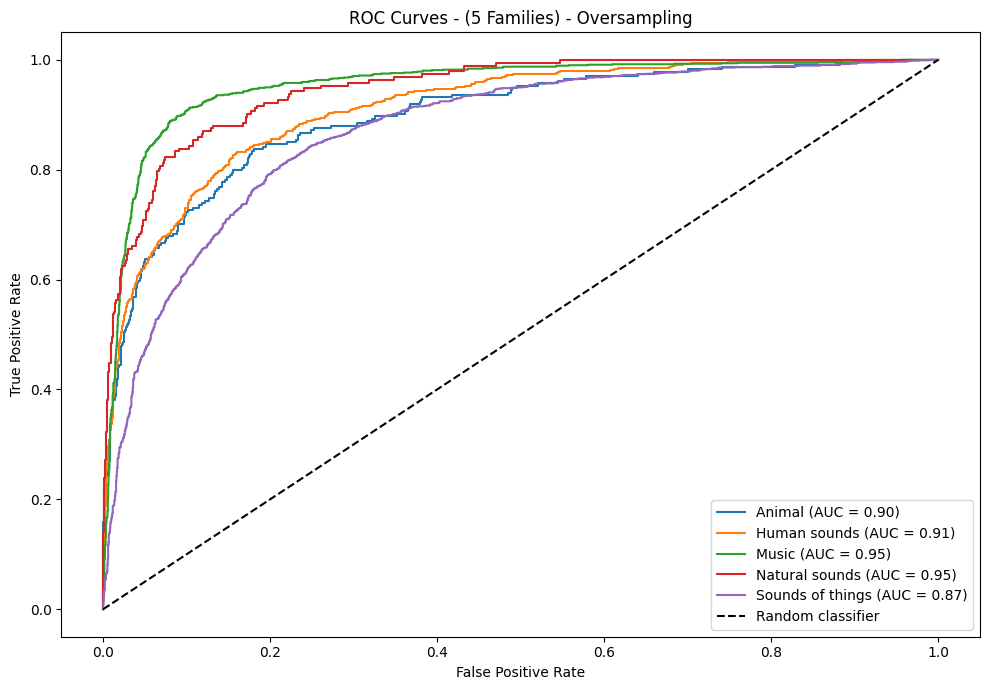

Calculating mAP for the validation set...
Mean Average Precision (mAP): 0.7335


In [16]:
# --- Get predicted probabilities for all val samples ---
model.eval()
all_probs = []
with torch.no_grad():
    for i in range(0, len(X_val_t_device), 256):
        xb = X_val_t_device[i:i+256]
        probs = torch.softmax(model(xb), dim=1).cpu().numpy()
        all_probs.append(probs)

all_probs = np.vstack(all_probs)  # (n_val_samples, 6)

# --- Binarize true labels for one-vs-rest ---
y_val_np = y_val_t.numpy()
y_bin = label_binarize(y_val_np, classes=list(range(n_classes)))  # (n_val_samples, 6)

# --- Plot ROC curves ---
plt.figure(figsize=(10, 7))
for i, class_name in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

print("Plotting ROC curves for each class...")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - (5 Families) - Oversampling")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("ROC_Curves_5_families_oversampling_{}.png".format(datetime.now().strftime('%Y-%m-%d %H:%M')))
plt.show()

#calculate the Mean accurate prediction (mAP) for the validation set
print("Calculating mAP for the validation set...")
from sklearn.metrics import average_precision_score
mAP = average_precision_score(y_bin, all_probs, average="macro")
print(f"Mean Average Precision (mAP): {mAP:.4f}")
#map_5 = average_precision_score(y_bin[:, :5], all_probs[:, :5], average="macro")
#print(f"Mean Average Precision (mAP) for the 5 classes (Excluding Source-Ambiguous Sounds): {map_5:.4f}")

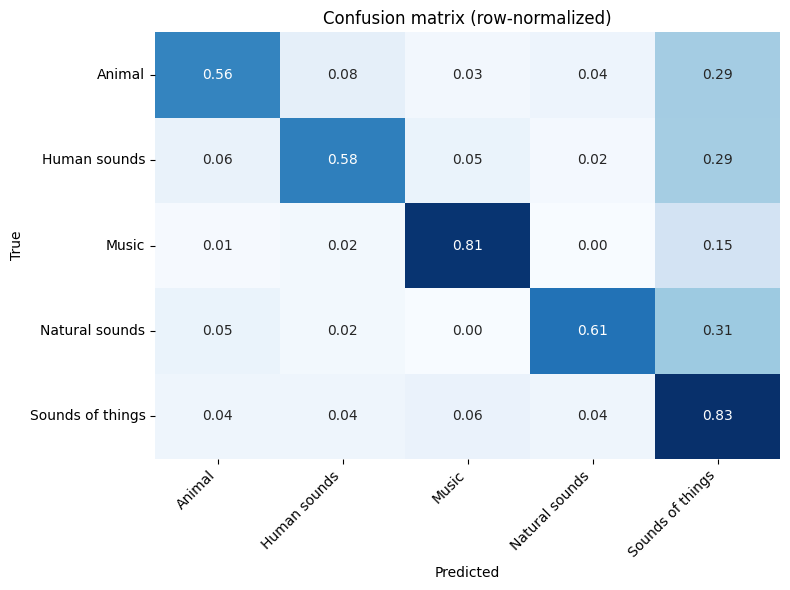

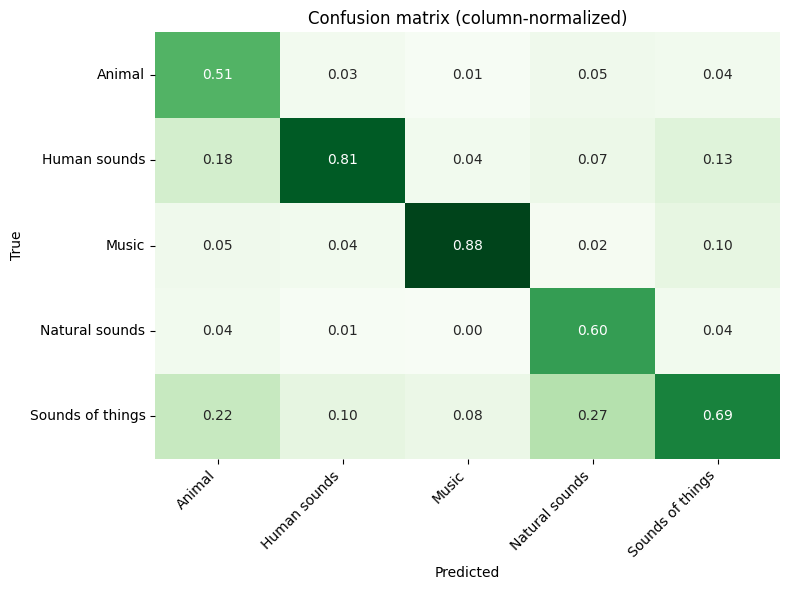

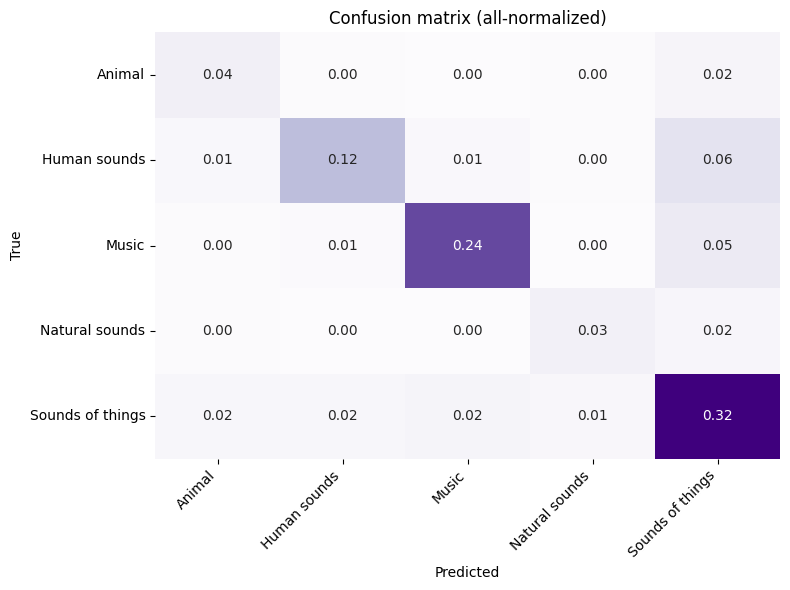

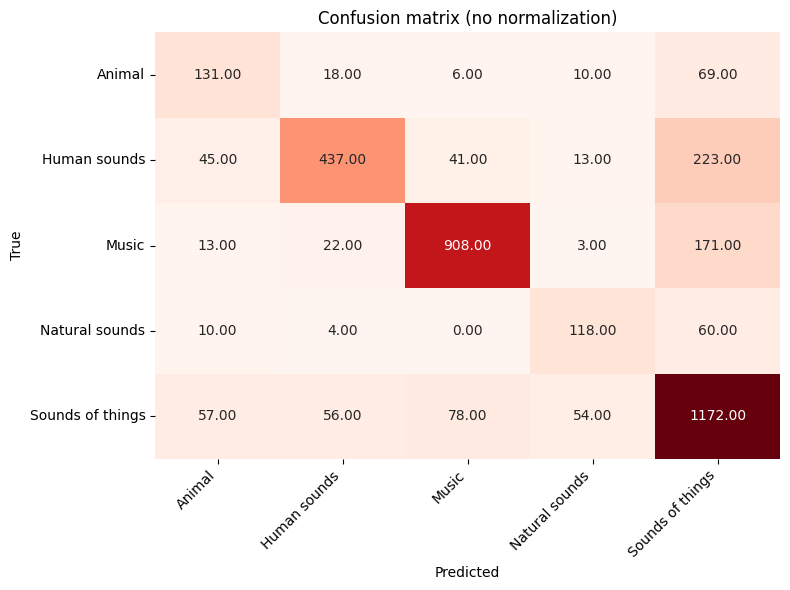

In [ ]:
# Get predictions on validation set
model.eval()
all_preds = []
with torch.no_grad():
    for i in range(0, len(X_val_t_device), 256):
        xb = X_val_t_device[i:i+256]
        preds = model(xb).argmax(1).cpu()
        all_preds.append(preds)

all_preds = torch.cat(all_preds).cpu().numpy()
y_val_np  = y_val_t.cpu().numpy()

# Confusion matrix
cm = confusion_matrix(y_val_np, all_preds, normalize='true')
cm_pred = confusion_matrix(y_val_np, all_preds, normalize='pred')
cm_all = confusion_matrix(y_val_np, all_preds, normalize='all')
cm_numbers = confusion_matrix(y_val_np, all_preds, normalize=None)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion matrix (row-normalized)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("confusion_matrix_5_families_{}.png".format(datetime.now().strftime('%Y-%m-%d %H:%M')), dpi=300)  # Save the confusion matrix as a high-resolution image
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(cm_pred, annot=True, fmt='.2f', cmap='Greens', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion matrix (column-normalized)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(cm_all, annot=True, fmt='.2f', cmap='Purples', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion matrix (all-normalized)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(cm_numbers, annot=True, fmt='.2f', cmap='Reds', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion matrix (no normalization)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Evaluation

In [6]:
# --- Load best saved model and predict on eval data ---

# 1. Extract eval spectrograms
print("Extracting spectrograms from eval split...")
spectrograms = []
valid_idx = []

for i, row in tqdm(eval_labels.iterrows(), total=len(eval_labels)):
    filepath = f"{DATA_PATH}/FSD50K.eval_audio/{row['fname']}.wav"
    spec = extract_spectrogram(filepath)
    if spec is not None:
        spectrograms.append(spec)
        valid_idx.append(i)

X_eval = np.array(spectrograms)
X_eval = X_eval[:, np.newaxis, :, :]
eval_true = eval_labels.loc[valid_idx].reset_index(drop=True)

# 2. Normalize using train stats (same mean/std as training!)
print(f"Importing stats for normalization and label encoding...")
folder = "models/Models_5_fam_oversampling/Models_5_fam_oversampling_2026-06-07 12:50"
MODEL_PATH = f"{folder}/5_model_map_0.7335_2026-06-07 12:50.pth" 
mean, std, dropout = np.load(f"{folder}/train_stats.npy")
le = LabelEncoder()
le.classes_ = np.load(f"{folder}/label_encoder_classes.npy", allow_pickle=True)
n_classes = len(le.classes_)
print(f"Normalizing eval data using train mean/std...")
X_eval = (X_eval - mean) / std


# 3. Assign family labels and filter out source-ambiguous sounds from both the metadata AND spectrograms
print(f"Assigning family labels to eval data...")
eval_true["family"] = eval_true["mids"].apply(lambda x: get_top_level_family(x.split(",")[0]))
mask = eval_true["family"] != "Source-ambiguous sounds"
eval_true = eval_true[mask].reset_index(drop=True)
X_eval = X_eval[mask.values]  
y_eval = le.transform(eval_true["family"])

# 4. Convert to tensors
print(f"Converting eval data to PyTorch tensors...")
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
X_eval_t = torch.tensor(X_eval, dtype=torch.float32).to(device)
y_eval_t = torch.tensor(y_eval, dtype=torch.long).to(device)

# 5. Load model
model_eval = AudioCNN_Optuna(n_classes, dropout=dropout).to(device)
model_eval.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=False))
model_eval.eval()
print(f"Loaded model from {MODEL_PATH}")

# 6. Predict
print(f"Predicting on eval data...")
all_probs_eval = []
with torch.no_grad():
    for i in range(0, len(X_eval_t), 256):
        xb = X_eval_t[i:i+256]
        probs = torch.softmax(model_eval(xb), dim=1).cpu().numpy()
        all_probs_eval.append(probs)

all_probs_eval = np.vstack(all_probs_eval)

# 7. Metrics
print(f"Calculating metrics on eval data...")
y_bin_eval = label_binarize(y_eval_t.cpu().numpy(), classes=list(range(n_classes)))
print(f"Shape of y_bin_eval: {y_bin_eval.shape}, Shape of all_probs_eval: {all_probs_eval.shape}")
eval_map = average_precision_score(y_bin_eval, all_probs_eval, average="macro")
eval_acc = (np.argmax(all_probs_eval, axis=1) == y_eval_t.cpu().numpy()).mean()

print("Successfully predicted on eval set!")
print(f"Eval Acc: {eval_acc:.3f} | Eval mAP: {eval_map:.3f}")

# 8. Save predictions with true and predicted family per file
pred_indices = np.argmax(all_probs_eval, axis=1)
eval_true["predicted_family"] = le.inverse_transform(pred_indices)
eval_true["correct"] = eval_true["family"] == eval_true["predicted_family"]
eval_true.to_csv(f"{folder}/5_eval_predictions.csv", index=False)
print("Predictions saved to 5_eval_predictions.csv")

Extracting spectrograms from eval split...


 40%|███▉      | 4077/10231 [00:27<00:38, 158.28it/s]/var/folders/cn/3wggtrs54wd25m8nnjtry4fh0000gn/T/ipykernel_36924/19858901.py:11: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(filepath, sr=TARGET_SR, duration=DURATION, mono=True)
/Users/livajuliesmidt/anaconda3/envs/app-ml/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
100%|██████████| 10231/10231 [01:06<00:00, 153.38it/s]


Importing stats for normalization and label encoding...
Normalizing eval data using train mean/std...
Assigning family labels to eval data...
Converting eval data to PyTorch tensors...
Loaded model from models/Models_5_fam_oversampling/Models_5_fam_oversampling_2026-06-07 12:50/5_model_map_0.7335_2026-06-07 12:50.pth
Predicting on eval data...
Calculating metrics on eval data...
Shape of y_bin_eval: (8799, 5), Shape of all_probs_eval: (8799, 5)
Successfully predicted on eval set!
Eval Acc: 0.677 | Eval mAP: 0.676
Predictions saved to 5_eval_predictions.csv


Plotting ROC curves for eval set...


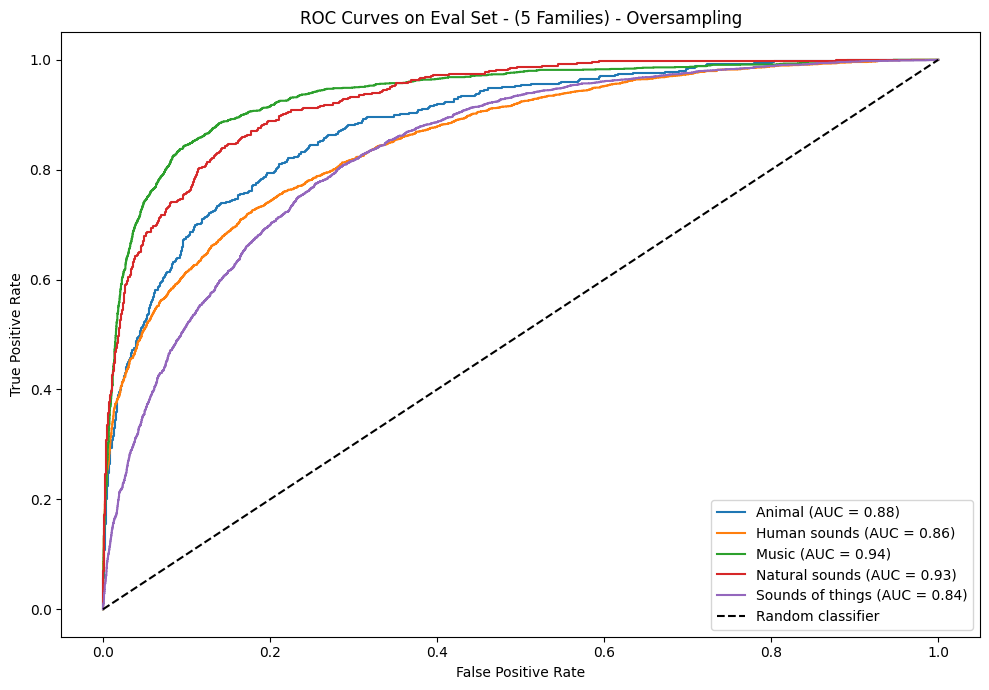

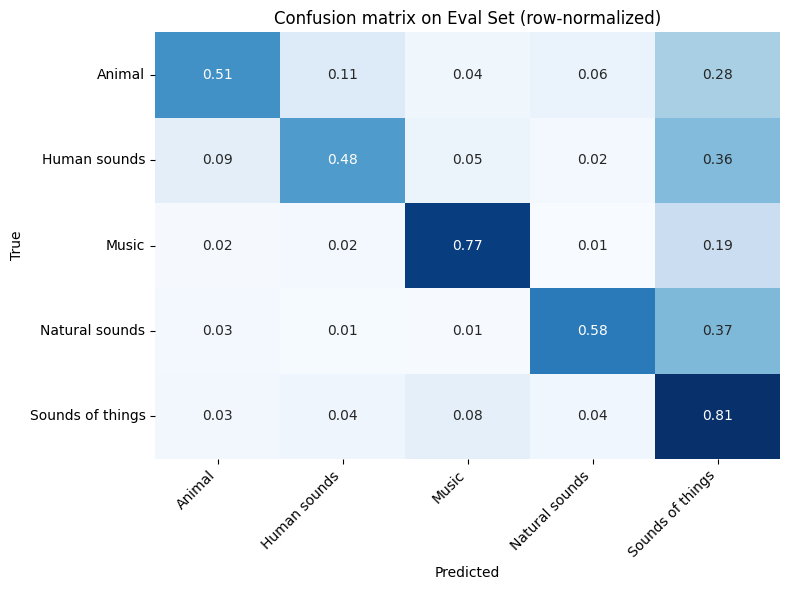

In [11]:
#Plotting ROC curves for eval set
plt.figure(figsize=(10, 7))
for i, class_name in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_bin_eval[:, i], all_probs_eval[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")
print("Plotting ROC curves for eval set...")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves on Eval Set - (5 Families) - Oversampling")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("ROC_Curves_Eval_5_families_oversampling_{}.png".format(datetime.now().strftime('%Y-%m-%d %H-%M')), dpi=300)
plt.show()

# Calculate confusion matrix for eval set
pred_labels_eval = np.argmax(all_probs_eval, axis=1)
cm_eval = confusion_matrix(y_eval_t.cpu().numpy(), pred_labels_eval, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm_eval, annot=True, fmt='.2f', cmap='Blues', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion matrix on Eval Set (row-normalized)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("confusion_matrix_eval_5{}.png".format(datetime.now().strftime('%Y-%m-%d %H-%M')), dpi=300)
plt.show()

## Guessing 10 sounds from eval set

In [ ]:
# --- Load best saved model and predict on eval data ---

# 0. importing stats
folder = "models/Models_5_fam_oversampling/Models_5_fam_oversampling_2026-06-07 12:50"
MODEL_PATH = f"{folder}/5_model_map_0.7335_2026-06-07 12:50.pth"  # update as needed
mean, std, dropout = np.load(f"{folder}/train_stats.npy")
le = LabelEncoder()
le.classes_ = np.load(f"{folder}/label_encoder_classes.npy", allow_pickle=True)
n_classes = len(le.classes_)

# 1. Extract eval spectrograms
spectrograms = []
valid_idx = []
eval_10_sounds = eval_labels.sample(n=15)

for i, row in tqdm(eval_10_sounds.iterrows(), total=len(eval_10_sounds)):
    filepath = f"{DATA_PATH}/FSD50K.eval_audio/{row['fname']}.wav"
    spec = extract_spectrogram(filepath)
    if spec is not None:
        spectrograms.append(spec)
        valid_idx.append(i)

X_eval = np.array(spectrograms)
X_eval = X_eval[:, np.newaxis, :, :]
eval_true = eval_10_sounds.loc[valid_idx].reset_index(drop=True)

# 2. Normalize using train stats (same mean/std as training!)
X_eval = (X_eval - mean) / std

# 3. Assign family labels and filter out source-ambiguous sounds from both the metadata AND spectrograms
eval_true["family"] = eval_true["mids"].apply(lambda x: get_top_level_family(x.split(",")[0]))
mask = eval_true["family"] != "Source-ambiguous sounds"
eval_true = eval_true[mask].reset_index(drop=True)
X_eval = X_eval[mask.values]  
y_eval = le.transform(eval_true["family"])

# 4. Convert to tensors
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
X_eval_t = torch.tensor(X_eval, dtype=torch.float32).to(device)
y_eval_t = torch.tensor(y_eval, dtype=torch.long).to(device)

# 5. Load model
model_eval = AudioCNN_Optuna(n_classes, dropout=dropout).to(device)
model_eval.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=False))
model_eval.eval()

# 6. Predict
all_probs_eval = []
with torch.no_grad():
    for i in range(0, len(X_eval_t), 256):
        xb = X_eval_t[i:i+256]
        probs = torch.softmax(model_eval(xb), dim=1).cpu().numpy()
        all_probs_eval.append(probs)

all_probs_eval = np.vstack(all_probs_eval)

# 7. Metrics
y_bin_eval = label_binarize(y_eval_t.cpu().numpy(), classes=list(range(n_classes)))
eval_map = average_precision_score(y_bin_eval, all_probs_eval, average="macro")
eval_acc = (np.argmax(all_probs_eval, axis=1) == y_eval_t.cpu().numpy()).mean()


# 8. Save predictions with true and predicted family per file
pred_indices = np.argmax(all_probs_eval, axis=1)
eval_true["predicted_family"] = le.inverse_transform(pred_indices)
eval_true["correct"] = eval_true["family"] == eval_true["predicted_family"]
guessing_file = eval_true[["family", "predicted_family", "correct"]]
guessing_file.to_csv(f"{folder}/5_families_guessing_10_sounds.csv", index=False)
guessing_file.head(10)

100%|██████████| 15/15 [00:00<00:00, 121.63it/s]
/Users/livajuliesmidt/anaconda3/envs/app-ml/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Users/livajuliesmidt/anaconda3/envs/app-ml/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


,family,predicted_family,correct
0,Music,Music,True
1,Sounds of things,Sounds of things,True
2,Sounds of things,Sounds of things,True
3,Sounds of things,Sounds of things,True
4,Music,Music,True
5,Sounds of things,Sounds of things,True
6,Sounds of things,Human sounds,False
7,Sounds of things,Sounds of things,True
8,Human sounds,Animal,False
9,Sounds of things,Sounds of things,True


## Guessing 10 sounds from youtube

In [48]:
# 0. importing stats
folder = "models/Models_5_fam_oversampling/Models_5_fam_oversampling_2026-06-07 12:50"
MODEL_PATH = f"{folder}/5_model_map_0.7335_2026-06-07 12:50.pth"
mean, std, dropout = np.load(f"{folder}/train_stats.npy")
le = LabelEncoder()
le.classes_ = np.load(f"{folder}/label_encoder_classes.npy", allow_pickle=True)
n_classes = len(le.classes_)

# 1. Download YouTube audio
url = "youtube.com/watch?v=VP6eZu3SAak&fbclid=IwY2xjawSSQs5leHRuA2FlbQIxMQBzcnRjBmFwcF9pZAEwAAEexWztuLqvnGzkhiqh-UwDo2u2cc89pQaVG70TucmiF3tm_LCSyjnAWNksuPY_aem_YxUqraqX7tkAvDXE3ks7FQ"
title = os.popen(f'yt-dlp --get-title "{url}"').read().strip()
safe_title = title.replace(" ", "_").replace("/", "-")  # make it filename-safe
os.system(f'yt-dlp -x --audio-format wav -o "{"Youtube_data"}/{safe_title}.wav" "{url}"')

# 2. Extract spectrogram from the YouTube file
spec = extract_spectrogram(f"{"Youtube_data"}/{safe_title}.wav")

if spec is None:
    print("Failed to extract spectrogram!")
else:
    X_eval = np.array([spec])[:, np.newaxis, :, :]  # shape (1, 1, 64, 216)

    # 3. Normalize
    X_eval = (X_eval - mean) / std

    # 4. Convert to tensor and predict
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    X_eval_t = torch.tensor(X_eval, dtype=torch.float32).to(device)

    model_eval = AudioCNN_Optuna(n_classes, dropout=dropout).to(device)
    model_eval.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=False))
    model_eval.eval()

    with torch.no_grad():
        probs = torch.softmax(model_eval(X_eval_t), dim=1).cpu().numpy()[0]

    predicted_class = le.classes_[np.argmax(probs)]
    print(f"\nCNN prediction for YouTube audio: {safe_title}")
    print(f"Predicted family: {predicted_class}")
    for cls, prob in zip(le.classes_, probs):
        print(f"  {cls}: {prob:.3f}")


[generic] Extracting URL: youtube.com/watch?v=VP6eZu3SAak&fbclid=IwY2xjawSSQs5leHRuA2FlbQIxMQBzcnRjBmFwcF9pZAEwAAEexWztuLqv...UqraqX7tkAvDXE3ks7FQ
[youtube] Extracting URL: https://youtube.com/watch?v=VP6eZu3SAak&fbclid=IwY2xjawSSQs5leHRuA2FlbQIxMQBzcnRjBmFwcF9pZAEwAAEe...UqraqX7tkAvDXE3ks7FQ
[youtube] VP6eZu3SAak: Downloading webpage


[youtube] VP6eZu3SAak: Downloading android vr player API JSON
[info] VP6eZu3SAak: Downloading 1 format(s): 251
[download] Destination: Youtube_data/“Fahh”_-_meme_sound_effect.webm
[download] 100% of   41.18KiB in 00:00:00 at 554.05KiB/s   
[ExtractAudio] Destination: Youtube_data/“Fahh”_-_meme_sound_effect.wav
Deleting original file Youtube_data/“Fahh”_-_meme_sound_effect.webm (pass -k to keep)

CNN prediction for YouTube audio: “Fahh”_-_meme_sound_effect
Predicted family: Sounds of things
  Animal: 0.008
  Human sounds: 0.138
  Music: 0.009
  Natural sounds: 0.011
  Sounds of things: 0.834


## Guessing self-recorded sounds

In [ ]:
# 0. importing stats
folder = "models/Models_5_fam_oversampling/Models_5_fam_oversampling_2026-06-07 12:50"
MODEL_PATH = f"{folder}/5_model_map_0.7335_2026-06-07 12:50.pth"
mean, std, dropout = np.load(f"{folder}/train_stats.npy")
le = LabelEncoder()
le.classes_ = np.load(f"{folder}/label_encoder_classes.npy", allow_pickle=True)
n_classes = len(le.classes_)

emojis = {
    "Human sounds": "🧍🏻",
    "Animal": "🐶",
    "Music": "🎵",
    "Natural sounds": "🌳",
    "Sounds of things": "🔧",
    "Source-ambiguous sounds": "❓"}

Recording in 3...
Recording in 2...
Recording in 1...
🎙 Recording!
Done! Saving...
Saved to Recording_2026-06-07_15:11.wav


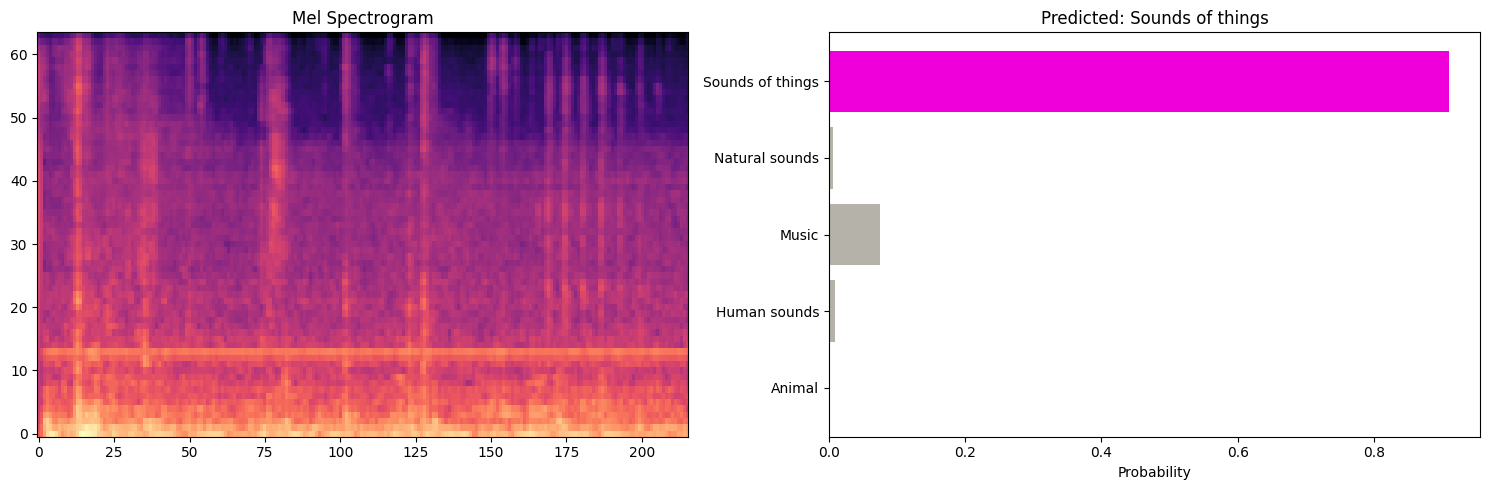

In [90]:
import matplotlib.font_manager as fm
#1 Record your own audio
DURATION = 5       # seconds to record
SAMPLE_RATE = 22050  # same as your model's TARGET_SR

print("Recording in 3...")
import time; time.sleep(1)
print("Recording in 2...")
time.sleep(1)
print("Recording in 1...")
time.sleep(1)
print("🎙 Recording!")

recording = sd.rec(int(DURATION * SAMPLE_RATE), samplerate=SAMPLE_RATE, channels=1)
sd.wait()  # wait until done

print("Done! Saving...")
save_path = "Recording_{}.wav".format(datetime.now().strftime('%Y-%m-%d_%H:%M'))
wav.write(save_path, SAMPLE_RATE, recording)
print(f"Saved to {save_path}")

# Predict
spec = extract_spectrogram(save_path)
if spec is None:
    print("Failed to extract spectrogram!")
else:
    X_eval = np.array([spec])[:, np.newaxis, :, :]
    X_eval = (X_eval - mean) / std
    X_eval_t = torch.tensor(X_eval, dtype=torch.float32).to(device)

    with torch.no_grad():
        probs = torch.softmax(model_eval(X_eval_t), dim=1).cpu().numpy()[0]

    predicted_class = le.classes_[np.argmax(probs)]
    fig, ax = plt.subplots(1,2, figsize=(15,5))
    classes = le.classes_
    ax[0].imshow(spec, aspect="auto", origin="lower", cmap="magma")
    ax[0].set_title("Mel Spectrogram")
    ax[1].barh(classes, probs, color=["#EF00DB" if c == predicted_class else "#B4B2A9" for c in classes])
    ax[1].set_xlabel("Probability")
    ax[1].set_title(f"Predicted: {predicted_class}")
    plt.tight_layout()
    plt.show()

from IPython.display import display, HTML
display(HTML(f"<div style='font-size:400px; text-align:center'>{emojis[predicted_class]}</div>"))

#delete the self-recorded file after prediction
os.remove(save_path)